# Mô hình Isolation Forest "Challenger" Không Giám Sát Phát Hiện Gian Lận Tài Chính

Notebook này triển khai pipeline huấn luyện cho mô hình **Isolation Forest** đóng vai trò là một **Challenger** không giám sát chạy ở **Chế độ Shadow (Shadow Mode)** song song với mô hình XGBoost **Champion**.

### Các mục tiêu chính:
1. **Huấn luyện Không Giám Sát Nghiêm Ngặt**: Tiền xử lý dữ liệu ngân hàng và cô lập/loại bỏ nhãn mục tiêu `is_fraud` trước khi huấn luyện, đảm bảo mô hình phát hiện bất thường một cách mù (blindly).
2. **Ước lượng tỷ lệ nhiễm bẩn (Contamination)**: Ước lượng động tham số contamination dựa trên tỷ lệ gian lận đã biết trong tập dữ liệu lịch sử.
3. **Chuyển đổi điểm rủi ro (Risk Score)**: Chuyển đổi điểm bất thường âm thô do hàm `decision_function()` của Isolation Forest trả về thành thang điểm Rủi ro chuẩn hóa `0 - 100` (100 = Rủi ro gian lận cao nhất) tương thích với khoảng điểm của mô hình champion XGBoost.
4. **Đánh giá Ngoại tuyến (Offline Evaluation)**: Đánh giá hiệu suất của mô hình không giám sát đối chiếu với nhãn ground truth thực tế qua các ngưỡng rủi ro khác nhau.
5. **Xuất Mô hình**: Lưu mô hình Isolation Forest đã huấn luyện dưới dạng file joblib để phục vụ triển khai trong Flink.

## 1. Thiết lập Môi trường

Cài đặt các gói Python cần thiết: `mlflow`

In [1]:
!pip install mlflow

## 2. Thư viện và Cấu hình

In [2]:
from __future__ import annotations

import json
import os
import warnings
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import joblib
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    precision_recall_curve,
    average_precision_score,
)

warnings.filterwarnings("ignore", category=UserWarning)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 100

## 3. Tải Dữ liệu

Chúng ta tải tập dữ liệu `ml_ready_data_csv` được tạo ra từ pipeline tính năng. Đây chính là nguồn dữ liệu được đưa vào mô hình XGBoost.
Thiết lập đường dẫn linh hoạt để tự động tìm file CSV trong môi trường local hoặc Google Colab.

In [3]:
# --- Cấu hình Đường dẫn Dữ liệu ---
# Hỗ trợ chạy trên IDE cục bộ (từ thư mục gốc dự án hoặc thư mục ml_training) và Google Colab
try:
    from google.colab import drive
    drive.mount("/content/drive")
    DATA_PATH = Path("/content/drive/MyDrive/Colab Notebooks/ml_fraud_features.csv")
except ImportError:
    # Nếu chạy local, tìm file CSV ở thư mục gốc
    DATA_PATH = Path("../ml_fraud_features.csv")


print(f"Loading data from: {DATA_PATH.resolve()}")
df_raw = pd.read_csv(DATA_PATH)
print(f"Dataset shape: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")
display(df_raw.head())

Mounted at /content/drive
Loading data from: /content/drive/MyDrive/Colab Notebooks/ml_fraud_features.csv
Dataset shape: 49,851 rows x 8 columns


,event_type,amount,ip_address,is_fraud,tx_count_1h,amount_avg_1h,amount_vs_avg,hour_of_day
0,LOGIN,0.00,172.16.83.213,0,1,0.000000e+00,0.0,16
1,VIEW_BALANCE,0.00,172.16.83.213,0,2,0.000000e+00,0.0,16
2,WITHDRAW,3660871.15,172.16.83.213,0,3,1.220290e+06,3.0,16
3,LOGOUT,0.00,172.16.83.213,0,4,9.152178e+05,0.0,16
4,LOGIN,0.00,172.16.55.205,0,1,0.000000e+00,0.0,0


## 4. Tiền xử lý Tính năng (Feature Preprocessing)

Chúng ta triển khai cùng một logic tiền xử lý như mô hình XGBoost để chuẩn bị các tính năng:
- **`ip_address`**: Frequency Encoding (mã hóa tần suất xuất hiện của mỗi IP).
- **`event_type`**: One-Hot Encoding (chuyển đổi các loại sự kiện thành các cột chỉ báo nhị phân).
- **Các cột số (Numerical)**: `amount`, `tx_count_1h`, `amount_avg_1h`, `amount_vs_avg`, `hour_of_day`.

In [11]:
FEATURE_COLS = [
    "event_type",
    "amount",
    "ip_address",
    "tx_count_1h",
    "amount_avg_1h",
    "amount_vs_avg",
    "hour_of_day",
]
TARGET_COL = "is_fraud"
NUMERIC_COLS = ["amount", "tx_count_1h", "amount_avg_1h", "amount_vs_avg", "hour_of_day"]

@dataclass
class FraudFeaturePreprocessor:
    """Khớp với logic tiền xử lý của mô hình XGBoost Champion."""
    event_type_categories: list[str] | None = None
    ip_frequency_map: dict[str, float] | None = None

    def fit(self, frame: pd.DataFrame) -> FraudFeaturePreprocessor:
        self.event_type_categories = sorted(frame["event_type"].astype(str).unique().tolist())
        ip_counts = frame["ip_address"].astype(str).value_counts()
        self.ip_frequency_map = ip_counts.to_dict()
        return self

    def transform(self, frame: pd.DataFrame) -> pd.DataFrame:
        if self.event_type_categories is None or self.ip_frequency_map is None:
            raise RuntimeError("Run fit() before transform().")

        working = frame.copy()

        # Mã hóa tần suất (Frequency encoding) cho IP
        working["ip_address_freq"] = (
            working["ip_address"]
            .astype(str)
            .map(self.ip_frequency_map)
            .fillna(0)
            .astype(np.float32)
        )

        # One-Hot Encoding cho event_type
        event_ohe = pd.get_dummies(
            working["event_type"].astype(str),
            prefix="event_type",
            dtype=np.float32,
        )
        for category in self.event_type_categories:
            col_name = f"event_type_{category}"
            if col_name not in event_ohe.columns:
                event_ohe[col_name] = 0.0
        event_ohe = event_ohe[[f"event_type_{c}" for c in self.event_type_categories]]

        numeric_part = working[NUMERIC_COLS].astype(np.float32)
        ip_part = working[["ip_address_freq"]]

        features = pd.concat([numeric_part, ip_part, event_ohe], axis=1)
        features = features.replace([np.inf, -np.inf], np.nan).fillna(0.0)
        return features

    def feature_names(self) -> list[str]:
        if self.event_type_categories is None:
            raise RuntimeError("Preprocessor has not been fit.")
        return NUMERIC_COLS + ["ip_address_freq"] + [
            f"event_type_{c}" for c in self.event_type_categories
        ]

    def to_artifact(self) -> dict:
        if self.event_type_categories is None or self.ip_frequency_map is None:
            raise RuntimeError("Preprocessor has not been fit.")
        return {
            "event_categories": self.event_type_categories,
            "ip_freq_map": self.ip_frequency_map
        }

# Khớp và biến đổi dữ liệu (Fit & Transform)
preprocessor = FraudFeaturePreprocessor().fit(df_raw[FEATURE_COLS])
df_features = preprocessor.transform(df_raw[FEATURE_COLS])

# Tái lắp ghép tập dữ liệu đã tiền xử lý 'df' bao gồm các tính năng + nhãn mục tiêu
df = df_features.copy()
df[TARGET_COL] = df_raw[TARGET_COL].astype(int).values

print(f"Preprocessed dataset shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Feature columns ({len(preprocessor.feature_names())}): {preprocessor.feature_names()}")
display(df.head())

Preprocessed dataset shape: 49,851 rows x 14 columns
Feature columns (13): ['amount', 'tx_count_1h', 'amount_avg_1h', 'amount_vs_avg', 'hour_of_day', 'ip_address_freq', 'event_type_LOGIN', 'event_type_LOGIN_FAILED', 'event_type_LOGIN_SUCCESS', 'event_type_LOGOUT', 'event_type_TRANSFER', 'event_type_VIEW_BALANCE', 'event_type_WITHDRAW']


,amount,tx_count_1h,amount_avg_1h,amount_vs_avg,hour_of_day,ip_address_freq,event_type_LOGIN,event_type_LOGIN_FAILED,event_type_LOGIN_SUCCESS,event_type_LOGOUT,event_type_TRANSFER,event_type_VIEW_BALANCE,event_type_WITHDRAW,is_fraud
0,0.00,1.0,0.000000e+00,0.0,16.0,4.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,0.00,2.0,0.000000e+00,0.0,16.0,4.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0
2,3660871.25,3.0,1.220290e+06,3.0,16.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0
3,0.00,4.0,9.152178e+05,0.0,16.0,4.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0
4,0.00,1.0,0.000000e+00,0.0,0.0,4.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0


## 5. Thiết lập Học Không Giám Sát & Cô lập Dữ liệu

Là một mô hình không giám sát, Isolation Forest phải được huấn luyện mà không được nhìn thấy nhãn.
Chúng ta loại bỏ cột `is_fraud` khỏi dữ liệu huấn luyện và tách nhãn `y_eval` ra riêng chỉ để phục vụ đánh giá sau khi huấn luyện.

In [5]:
# QUAN TRỌNG: Cô lập nhãn mục tiêu CHỈ cho mục đích đánh giá
y_eval = df[TARGET_COL].values

# Loại bỏ cột is_fraud khỏi dataframe huấn luyện
X_train = df.drop(columns=[TARGET_COL])

print(f"X_train features shape: {X_train.shape}")
print(f"X_train columns: {list(X_train.columns)}")
assert TARGET_COL not in X_train.columns, "LỖI NGHIÊM TRỌNG: Nhãn is_fraud bị rò rỉ vào dữ liệu huấn luyện!"

X_train features shape: (49851, 13)
X_train columns: ['amount', 'tx_count_1h', 'amount_avg_1h', 'amount_vs_avg', 'hour_of_day', 'ip_address_freq', 'event_type_LOGIN', 'event_type_LOGIN_FAILED', 'event_type_LOGIN_SUCCESS', 'event_type_LOGOUT', 'event_type_TRANSFER', 'event_type_VIEW_BALANCE', 'event_type_WITHDRAW']


## 6. Huấn luyện Isolation Forest

Tham số `contamination` xác định tỷ lệ ngoại lai (outliers) trong dữ liệu. Chúng ta ước lượng tham số này bằng cách sử dụng tỷ lệ gian lận lịch sử trong tập dữ liệu (tỷ lệ các giá trị 1 của cột `is_fraud`).

In [6]:
# Ước lượng tham số contamination dựa trên tỷ lệ gian lận đã biết
contamination = float(np.mean(y_eval))
print(f"Tham số contamination ước lượng (tỷ lệ gian lận lịch sử): {contamination:.6f} (~{contamination*100:.2f}%)")

# Khởi tạo bộ phân lớp Isolation Forest
# Thiết lập random_state=RANDOM_STATE để đảm bảo tính tái lập
iso_forest = IsolationForest(
    n_estimators=150,
    contamination=contamination,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

print("Đang huấn luyện mô hình Isolation Forest trên X_train...")
iso_forest.fit(X_train)
print("Huấn luyện hoàn tất!")

Estimated contamination parameter (historical fraud ratio): 0.354496 (~35.45%)
Training Isolation Forest model on X_train...
Training completed!


## 7. Tính Điểm & Ánh xạ Rủi ro (Logic Chế độ Shadow)

Hàm `decision_function()` của Isolation Forest trả về điểm bất thường trong đó:
- Các điểm ngoại lai (bất thường) có điểm **âm**.
- Các điểm bình thường có điểm **dương**.

Để triển khai mô hình challenger này song song với mô hình champion XGBoost, chúng ta cần biến đổi các điểm này sang **thang điểm Rủi ro từ 0 đến 100**, trong đó **100 đại diện cho rủi ro gian lận cao nhất**.
Chúng ta áp dụng công thức chuẩn hóa Min-Max trên điểm bất thường đã đảo ngược:
$$RiskScore = 100 \times \frac{s_{\max} - s}{s_{\max} - s_{\min}}$$

Để phục vụ dự báo thời gian thực (streaming inference) trong Flink, chúng ta sẽ lưu lại điểm thô tối thiểu (min) và tối đa (max) từ tập huấn luyện để ánh xạ các sự kiện thực tế một cách nhất quán.

Raw anomaly scores range: [-0.22669, 0.08553]

Sample of Risk Scores vs. Ground Truth:


,is_fraud,risk_score
0,0,6.549219
1,0,3.204656
2,0,27.457688
3,0,1.319278
4,0,22.416548
5,0,16.728908
6,0,37.297921
7,0,14.588489
8,0,16.996218
9,0,12.431929


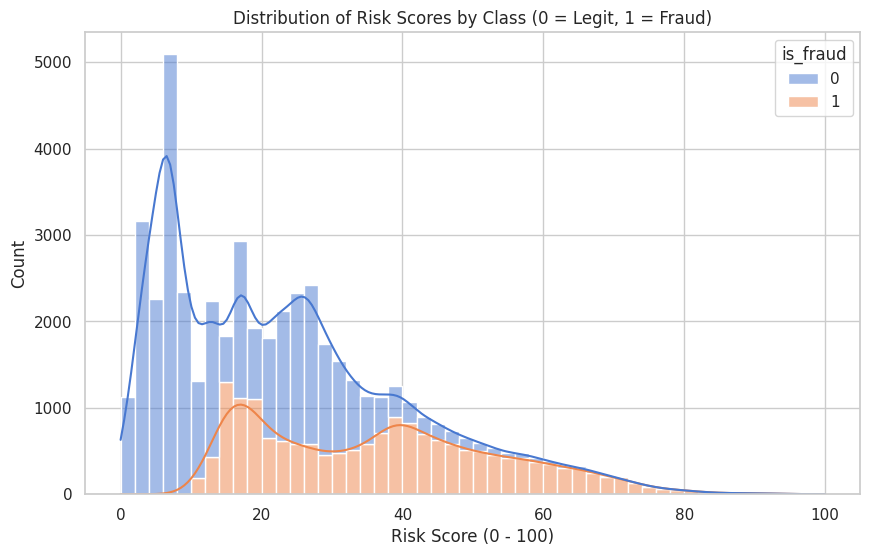

In [7]:
# Lấy điểm bất thường thô
raw_scores = iso_forest.decision_function(X_train)

# Xác định điểm nhỏ nhất và lớn nhất trong tập huấn luyện
raw_min = float(raw_scores.min())
raw_max = float(raw_scores.max())
print(f"Phạm vi điểm bất thường thô: [{raw_min:.5f}, {raw_max:.5f}]")

# Ánh xạ điểm thô sang thang điểm Rủi ro [0, 100]
# Điểm raw_score càng thấp = càng bất thường = điểm rủi ro càng cao
risk_scores = 100.0 * (raw_max - raw_scores) / (raw_max - raw_min)

# Lưu điểm rủi ro vào dataframe
df["risk_score"] = risk_scores

print("\nMẫu điểm Rủi ro so với Ground Truth (Thực tế):")
display(df[[TARGET_COL, "risk_score"]].head(10))

# Vẽ biểu đồ phân phối điểm Rủi ro cho Fraud vs. Legit
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x="risk_score", hue=TARGET_COL, kde=True, bins=50, multiple="stack")
plt.title("Phân phối điểm Rủi ro theo Lớp (0 = Hợp lệ, 1 = Gian lận)")
plt.xlabel("Điểm Rủi ro (0 - 100)")
plt.ylabel("Số lượng")
plt.show()

## 8. Đánh giá Đối chiếu với Thực tế (Ground Truth)

Chúng ta chuyển đổi điểm rủi ro liên tục thành các dự báo nhị phân dựa trên một ngưỡng rủi ro xác định (ví dụ: Risk Score > 90) và đánh giá bằng Precision, Recall, và F1-Score.

Evaluating model at Risk Score threshold: > 90.0

Classification Report:
              precision    recall  f1-score   support

           0     0.6458    1.0000    0.7848     32179
           1     1.0000    0.0014    0.0028     17672

    accuracy                         0.6460     49851
   macro avg     0.8229    0.5007    0.3938     49851
weighted avg     0.7714    0.6460    0.5076     49851

Precision: 1.0000
Recall:    0.0014
F1-Score:  0.0028


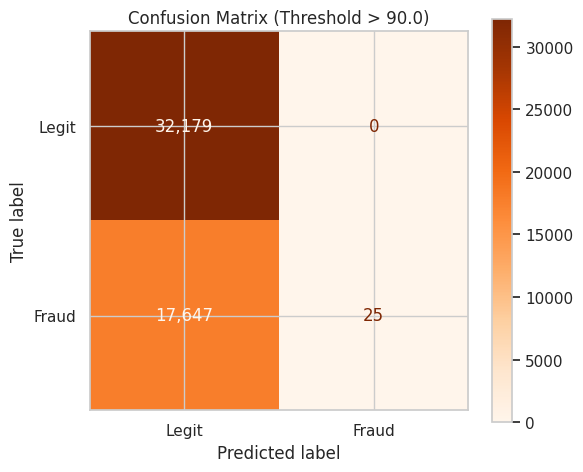

In [8]:
# Định nghĩa ngưỡng để chuyển đổi điểm rủi ro thành dự báo nhị phân
threshold = 90.0
print(f"Đang đánh giá mô hình tại ngưỡng Điểm Rủi ro: > {threshold}")

y_pred = (df["risk_score"] > threshold).astype(int)

# Báo cáo Phân lớp
print("\nBáo cáo Phân lớp:")
print(classification_report(y_eval, y_pred, digits=4))

# Tính toán các độ đo
prec = precision_score(y_eval, y_pred)
rec = recall_score(y_eval, y_pred)
f1 = f1_score(y_eval, y_pred)

print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-Score:  {f1:.4f}")

# Vẽ Ma trận nhầm lẫn (Confusion Matrix)
cm = confusion_matrix(y_eval, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Legit", "Fraud"]).plot(
    cmap="Oranges", ax=ax, values_format=","
)
ax.set_title(f"Ma trận nhầm lẫn (Ngưỡng > {threshold})")
plt.tight_layout()
plt.show()

### 8.1 Tinh chỉnh Ngưỡng (Threshold Tuning)

Hãy đánh giá sự thay đổi của Precision, Recall, và F1-Score qua các ngưỡng khác nhau. Điều này giúp tìm ra ngưỡng tối ưu cho các mục tiêu kinh doanh khác nhau (ví dụ: recall cao để bắt hết gian lận hoặc precision cao để tránh cảnh báo giả).

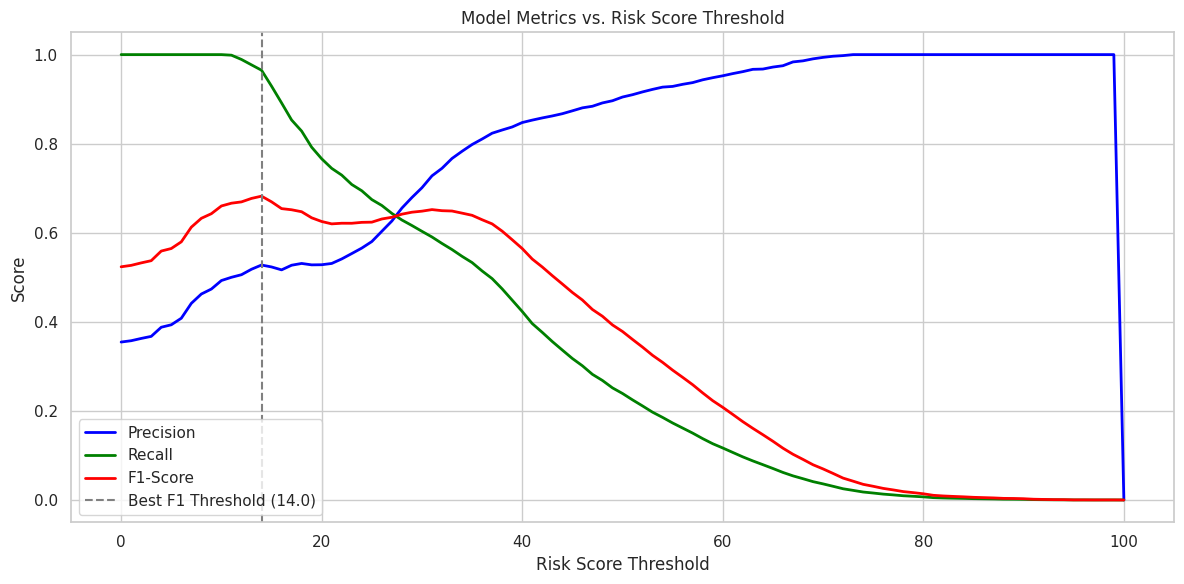

Optimal F1 threshold: 14.0 with F1-Score: 0.6822


In [9]:
thresholds = np.linspace(0, 100, 101)
precisions = []
recalls = []
f1_scores = []

for t in thresholds:
    pred = (df["risk_score"] > t).astype(int)
    precisions.append(precision_score(y_eval, pred, zero_division=0))
    recalls.append(recall_score(y_eval, pred, zero_division=0))
    f1_scores.append(f1_score(y_eval, pred, zero_division=0))

# Vẽ biểu đồ các độ đo theo Ngưỡng
plt.figure(figsize=(12, 6))
plt.plot(thresholds, precisions, label="Precision", color="blue", lw=2)
plt.plot(thresholds, recalls, label="Recall", color="green", lw=2)
plt.plot(thresholds, f1_scores, label="F1-Score", color="red", lw=2)

# Đánh dấu ngưỡng F1 tốt nhất
best_idx = np.argmax(f1_scores)
best_t = thresholds[best_idx]
best_f1 = f1_scores[best_idx]
plt.axvline(best_t, color="gray", linestyle="--", label=f"Ngưỡng F1 tốt nhất ({best_t:.1f})")

plt.title("Các độ đo mô hình so với Ngưỡng Điểm Rủi ro")
plt.xlabel("Ngưỡng Điểm Rủi ro")
plt.ylabel("Điểm số")
plt.legend(loc="lower left")
plt.tight_layout()
plt.show()

print(f"Ngưỡng F1 tối ưu: {best_t:.1f} với F1-Score: {best_f1:.4f}")

## 9. Xuất Mô hình

Chúng ta lưu mô hình Isolation Forest đã huấn luyện thành file `isolation_forest_model.joblib`. Đồng thời xuất các siêu dữ liệu (metadata) đi kèm (preprocessor artifact, khoảng min/max của điểm thô để chuẩn hóa điểm rủi ro) nhằm đảm bảo tính tái lập chuẩn hóa dữ liệu.

In [12]:
MODEL_EXPORT_PATH = Path("isolation_forest_model.joblib")
METADATA_EXPORT_PATH = Path("isolation_forest_metadata.joblib")

# Lưu mô hình
joblib.dump(iso_forest, MODEL_EXPORT_PATH)

# Lưu siêu dữ liệu (metadata)
metadata = {
    "raw_min": raw_min,
    "raw_max": raw_max,
    "contamination": contamination,
    "feature_names": preprocessor.feature_names(),
    "preprocessor_artifact": preprocessor.to_artifact(),
}
joblib.dump(metadata, METADATA_EXPORT_PATH)

print(f"Đã lưu mô hình Isolation Forest: {MODEL_EXPORT_PATH.resolve()} ({MODEL_EXPORT_PATH.stat().st_size / 1024:.1f} KB)")
print(f"Đã lưu siêu dữ liệu mô hình: {METADATA_EXPORT_PATH.resolve()} ({METADATA_EXPORT_PATH.stat().st_size / 1024:.1f} KB)")

Saved Isolation Forest model: /content/isolation_forest_model.joblib (1926.1 KB)
Saved model metadata: /content/isolation_forest_metadata.joblib (134.9 KB)


## 10. Hướng dẫn Tích hợp Chế độ Shadow & Flink

Để chạy mô hình Challenger trong PyFlink/Python Shadow Mode song song với mô hình Champion XGBoost, hãy thực hiện các bước sau:

1. **Tải các Artifacts**:
   ```python
   import joblib
   import numpy as np

   model = joblib.load("isolation_forest_model.joblib")
   metadata = joblib.load("isolation_forest_metadata.joblib")
   raw_min = metadata["raw_min"]
   raw_max = metadata["raw_max"]
   ```

2. **Hàm Dự báo**:
   ```python
   def predict_risk_score(feature_vector: np.ndarray) -> float:
       # Lấy điểm bất thường thô từ Isolation Forest
       # Reshape cho mẫu đơn lẻ (single sample)
       raw_score = model.decision_function(feature_vector.reshape(1, -1))[0]
       
       # Chuẩn hóa về khoảng [0, 100]
       risk_score = 100.0 * (raw_max - raw_score) / (raw_max - raw_min)
       
       # Clip về khoảng [0, 100] để xử lý các sự kiện streaming nằm ngoài phạm vi huấn luyện
       return float(np.clip(risk_score, 0.0, 100.0))
   ```